In [1]:
import quantax as qtx

### ED


(1, 4, 4)


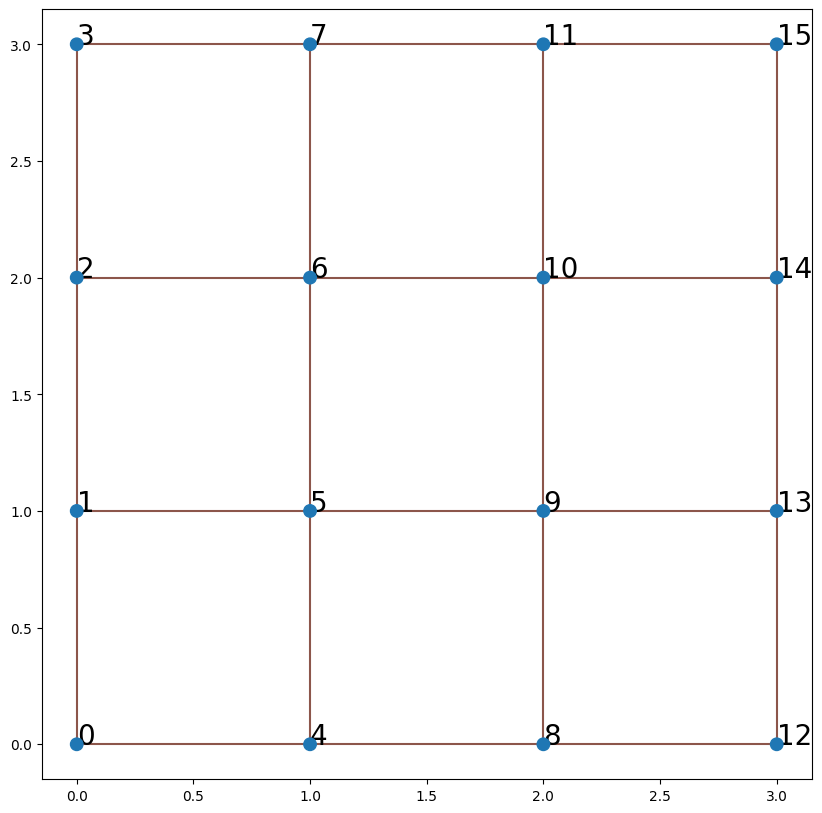

In [2]:
import matplotlib.pyplot as plt

# 4x4 square lattice, PBC by default, 8 spin-up, 8 spin-down
lattice = qtx.sites.Square(4, Nparticles=(8, 8))

print(lattice.shape)  # output: (1, 4, 4), 1 spin per unit cell, and Lx = Ly = 4
lattice.plot()
plt.show()

In [3]:
# Define Heisenberg Hamiltonian

# Method 1: Using built-in operator
H = qtx.operator.Heisenberg()


# Method2: Customized operator
from quantax.operator import sigma_m, sigma_p, sigma_z

H = 0

Lx, Ly = lattice.shape[1:]
for x in range(Lx):
    for y in range(Ly):
        # Periodic boundary taken into account automatically
        H += sigma_z(x, y) @ sigma_z(x + 1, y) + sigma_z(x, y) @ sigma_z(x, y + 1)
        H += 2 * (sigma_m(x, y) @ sigma_p(x + 1, y) + sigma_p(x, y) @ sigma_m(x + 1, y))
        H += 2 * (sigma_m(x, y) @ sigma_p(x, y + 1) + sigma_p(x, y) @ sigma_m(x, y + 1))

print(H)

+4.0 Sᶻ₀ Sᶻ₄ +4.0 Sᶻ₀ Sᶻ₁ +4.0 Sᶻ₁ Sᶻ₅ +4.0 Sᶻ₁ Sᶻ₂ +4.0 Sᶻ₂ Sᶻ₆ +4.0 Sᶻ₂ Sᶻ₃ +4.0 Sᶻ₃ Sᶻ₇ +4.0 Sᶻ₃ Sᶻ₀ +4.0 Sᶻ₄ Sᶻ₈ +4.0 Sᶻ₄ Sᶻ₅ +4.0 Sᶻ₅ Sᶻ₉ +4.0 Sᶻ₅ Sᶻ₆ +4.0 Sᶻ₆ Sᶻ₁₀ +4.0 Sᶻ₆ Sᶻ₇ +4.0 Sᶻ₇ Sᶻ₁₁ +4.0 Sᶻ₇ Sᶻ₄ +4.0 Sᶻ₈ Sᶻ₁₂ +4.0 Sᶻ₈ Sᶻ₉ +4.0 Sᶻ₉ Sᶻ₁₃ +4.0 Sᶻ₉ Sᶻ₁₀ +4.0 Sᶻ₁₀ Sᶻ₁₄ +4.0 Sᶻ₁₀ Sᶻ₁₁ +4.0 Sᶻ₁₁ Sᶻ₁₅ +4.0 Sᶻ₁₁ Sᶻ₈ +4.0 Sᶻ₁₂ Sᶻ₀ +4.0 Sᶻ₁₂ Sᶻ₁₃ +4.0 Sᶻ₁₃ Sᶻ₁ +4.0 Sᶻ₁₃ Sᶻ₁₄ +4.0 Sᶻ₁₄ Sᶻ₂ +4.0 Sᶻ₁₄ Sᶻ₁₅ +4.0 Sᶻ₁₅ Sᶻ₃ +4.0 Sᶻ₁₅ Sᶻ₁₂ +2.0 S⁻₀ S⁺₄ +2.0 S⁻₀ S⁺₁ +2.0 S⁻₁ S⁺₅ +2.0 S⁻₁ S⁺₂ +2.0 S⁻₂ S⁺₆ +2.0 S⁻₂ S⁺₃ +2.0 S⁻₃ S⁺₇ +2.0 S⁻₃ S⁺₀ +2.0 S⁻₄ S⁺₈ +2.0 S⁻₄ S⁺₅ +2.0 S⁻₅ S⁺₉ +2.0 S⁻₅ S⁺₆ +2.0 S⁻₆ S⁺₁₀ +2.0 S⁻₆ S⁺₇ +2.0 S⁻₇ S⁺₁₁ +2.0 S⁻₇ S⁺₄ +2.0 S⁻₈ S⁺₁₂ +2.0 S⁻₈ S⁺₉ +2.0 S⁻₉ S⁺₁₃ +2.0 S⁻₉ S⁺₁₀ +2.0 S⁻₁₀ S⁺₁₄ +2.0 S⁻₁₀ S⁺₁₁ +2.0 S⁻₁₁ S⁺₁₅ +2.0 S⁻₁₁ S⁺₈ +2.0 S⁻₁₂ S⁺₀ +2.0 S⁻₁₂ S⁺₁₃ +2.0 S⁻₁₃ S⁺₁ +2.0 S⁻₁₃ S⁺₁₄ +2.0 S⁻₁₄ S⁺₂ +2.0 S⁻₁₄ S⁺₁₅ +2.0 S⁻₁₅ S⁺₃ +2.0 S⁻₁₅ S⁺₁₂ +2.0 S⁺₀ S⁻₄ +2.0 S⁺₀ S⁻₁ +2.0 S⁺₁ S⁻₅ +2.0 S⁺₁ S⁻₂ +2.0 S⁺₂ S⁻₆ +2.0 S⁺₂ S⁻₃ +2.0 S⁺₃ S⁻₇ +2.0 S⁺₃ S⁻₀ +2.0 S⁺₄ S⁻₈ +2.

In [4]:
E, wf = H.diagonalize(k=2)

dense0 = qtx.state.DenseState(wf[:, 0])  # Ground state
dense1 = qtx.state.DenseState(wf[:, 1])  # First excited state

In [5]:
s = qtx.utils.rand_states()
print("s =", s)  # +1/-1 represents spin-up/down
print("<s|psi0> =", dense0(s))

s = [ 1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1 -1  1 -1]
<s|psi0> = [-0.00286136]


In [6]:
print("<psi0|psi0> =", dense0 @ dense0)  # output: 1, normalization
print("<psi0|psi1> =", dense0 @ dense1)  # output: 0, orthogonality

print("<psi0|H|psi0> =", dense0 @ H @ dense0, "\t", "E0 =", E[0])
print("<psi1|H|psi1> =", dense1 @ H @ dense1, "\t", "E1 =", E[1])

<psi0|psi0> = 1.0000000000000007
<psi0|psi1> = 3.3306690738754696e-16
<psi0|H|psi0> = -44.913932833715464 	 E0 = -44.9139328337155
<psi1|H|psi1> = -42.5995394906538 	 E1 = -42.599539490653775
